# Исследование: Ассортиментная матрица маркетплейса (2023)

**Данные:** таблица `purchases`, период 01.01.2023 — 31.12.2023, 2 040 076 транзакций

---

## 1. Цель и подход

Цель — ответить на вопрос: какие товары приносят основную выручку, 
какие стабильны в спросе, а какие являются балластом?

Методология: **ABC×XYZ-анализ**
- **ABC** — классификация по доле в выручке (A: топ 80%, B: следующие 15%, C: хвост 5%)
- **XYZ** — классификация по стабильности недельного спроса (коэффициент вариации CV)

Дополнительно: анализ скидок и их влияния на объём продаж.

**Ограничения данных:** себестоимость отсутствует — работаем с выручкой (`total_price`) 
и упущенной суммой от скидок. Скидки в данных равномерно распределены от 0 до 100% — 
особенность синтетического датасета.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv(override=True)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)
print("Подключение создано")

Подключение создано


## 2. Загрузка данных

Подключение к PostgreSQL через SSH-туннель (локальный порт 15432 → сервер 5432).
Загружаем все транзакции за 2023 год одним запросом.

In [20]:
query = """
    SELECT
        client_id,
        product_id,
        purchase_date,
        quantity,
        price_per_item,
        discount_per_item,
        total_price
    FROM purchases
    WHERE purchase_date >= '2023-01-01'
      AND purchase_date <= '2023-12-31'
"""

df = pd.read_sql(
    query, 
    engine,
    dtype={
        'client_id': 'int32',
        'product_id': 'int32',
        'quantity': 'int16',
        'price_per_item': 'int32',
        'discount_per_item': 'int32',
        'total_price': 'int32'
    }
)
print(f"Загружено строк: {len(df):,}")
print(f"Период: {df['purchase_date'].min()} — {df['purchase_date'].max()}")
print(f"Уникальных товаров: {df['product_id'].nunique():,}")
print(f"Уникальных клиентов: {df['client_id'].nunique():,}")

Загружено строк: 2,040,076
Период: 2023-01-01 — 2023-12-31
Уникальных товаров: 50,000
Уникальных клиентов: 869,966


## 3. Первичный анализ

Общая картина по данным: динамика выручки, распределение скидок, топ товаров.

In [21]:
# всё считаем из df локально — больше к БД не обращаемся

# товары
df_products = df.groupby('product_id').agg(
    revenue=('total_price', 'sum'),
    total_qty=('quantity', 'sum'),
    total_discount=('discount_per_item', lambda x: (x * df.loc[x.index, 'quantity']).sum()),
    avg_discount_rate=('discount_per_item', lambda x: (x / df.loc[x.index, 'price_per_item'].replace(0, float('nan'))).mean()),
    line_count=('product_id', 'count')
).reset_index()

# недельная выручка по товарам
df['week'] = pd.to_datetime(df['purchase_date']).dt.isocalendar().week.astype(int)
df_weekly = df.groupby(['product_id', 'week'])['total_price'].sum().reset_index()
df_weekly.columns = ['product_id', 'week', 'weekly_revenue']

# дневная выручка
df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df_daily = df.groupby('purchase_date')['total_price'].sum().reset_index()
df_daily.columns = ['purchase_date', 'daily_revenue']

print(f"Товаров: {len(df_products):,}")
print(f"Недельных записей: {len(df_weekly):,}")
print(f"Дней: {len(df_daily):,}")

Товаров: 50,000
Недельных записей: 1,403,570
Дней: 365


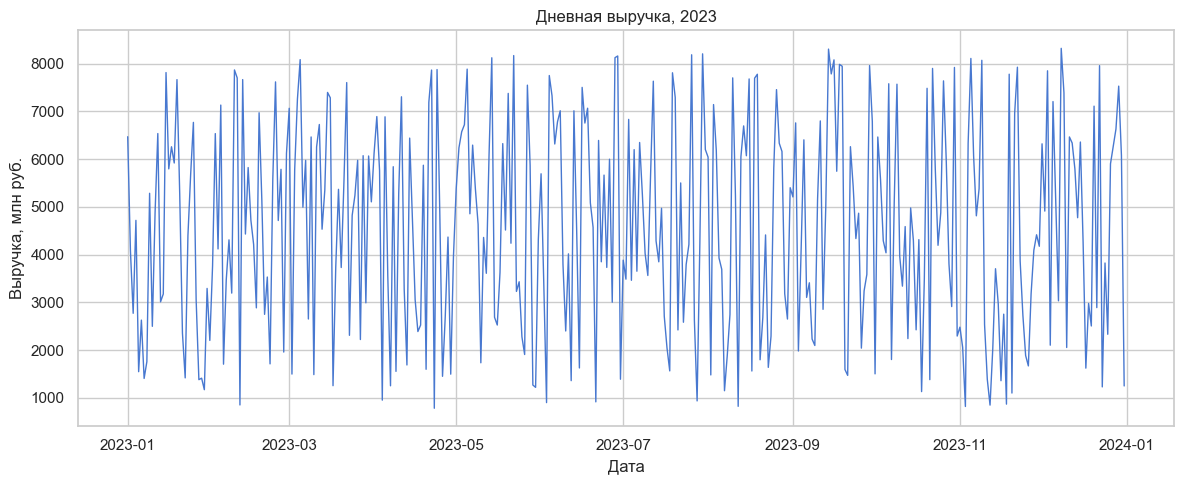

In [22]:
# дневная выручка

fig, ax = plt.subplots()
ax.plot(df_daily['purchase_date'], df_daily['daily_revenue'] / 1e6, linewidth=1)
ax.set_title('Дневная выручка, 2023')
ax.set_xlabel('Дата')
ax.set_ylabel('Выручка, млн руб.')
plt.tight_layout()
plt.show()

**Комментарий**

Дневная выручка варьируется от ~1 до ~8 млрд руб. без выраженного тренда и сезонности.
Характерна высокая день-ко-дню волатильность — типично для синтетических данных.

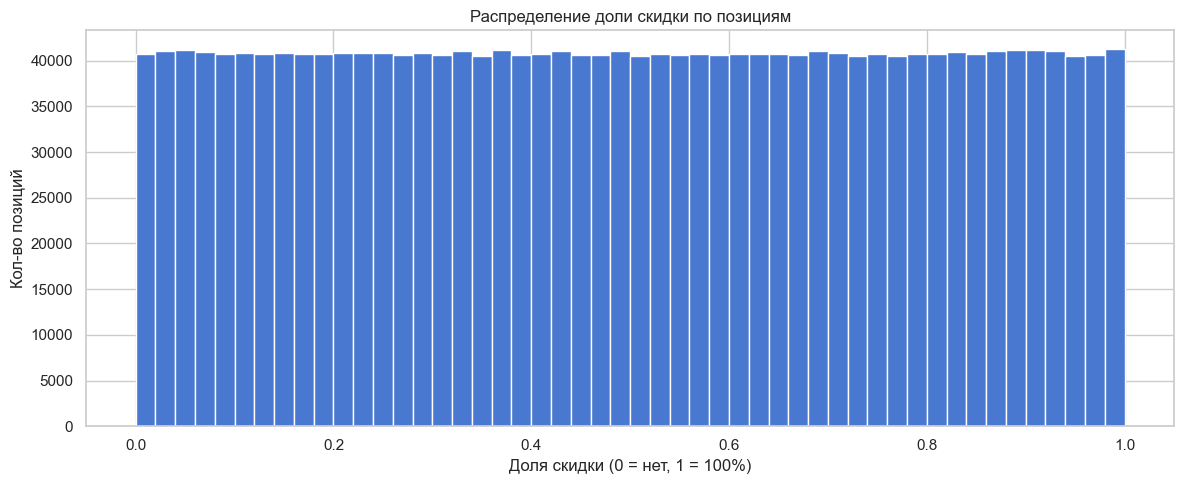

Позиций без скидки: 231 (0.0%)
Позиций со скидкой >50%: 1,019,457 (50.0%)


In [23]:
# Распределение доли скидки по позициям

df['discount_rate'] = df['discount_per_item'] / df['price_per_item'].replace(0, float('nan'))

fig, ax = plt.subplots()
ax.hist(df['discount_rate'].dropna(), bins=50, edgecolor='white')
ax.set_title('Распределение доли скидки по позициям')
ax.set_xlabel('Доля скидки (0 = нет, 1 = 100%)')
ax.set_ylabel('Кол-во позиций')
plt.tight_layout()
plt.show()

print(f"Позиций без скидки: {(df['discount_rate'] == 0).sum():,} ({(df['discount_rate'] == 0).mean():.1%})")
print(f"Позиций со скидкой >50%: {(df['discount_rate'] > 0.5).sum():,} ({(df['discount_rate'] > 0.5).mean():.1%})")

**Комментарий**

Скидки распределены равномерно от 0 до 100% — особенность синтетического датасета.
99.9% позиций имеют скидку, у 50% позиций скидка превышает 50% цены.

## 4. ABC-анализ по выручке

Классифицируем товары по доле в суммарной выручке за 2023 год.
- Класс A: товары, формирующие первые 80% выручки
- Класс B: следующие 15%
- Класс C: оставшиеся 5%

In [24]:
# ABC

abc = df_products[['product_id', 'revenue']].sort_values('revenue', ascending=False).reset_index(drop=True)
total_rev = abc['revenue'].sum()
abc['cumshare'] = abc['revenue'].cumsum() / total_rev

def abc_class(cumshare):
    if cumshare <= 0.80:
        return 'A'
    elif cumshare <= 0.95:
        return 'B'
    else:
        return 'C'

abc['abc'] = abc['cumshare'].apply(abc_class)

summary_abc = abc.groupby('abc').agg(
    товаров=('product_id', 'count'),
    выручка=('revenue', 'sum')
).reindex(['A', 'B', 'C'])
summary_abc['доля_товаров_%'] = (summary_abc['товаров'] / len(abc) * 100).round(1)
summary_abc['доля_выручки_%'] = (summary_abc['выручка'] / total_rev * 100).round(1)
display(summary_abc[['товаров', 'доля_товаров_%', 'доля_выручки_%']])

,товаров,доля_товаров_%,доля_выручки_%
abc,,,
A,26996,54.0,80.0
B,11509,23.0,15.0
C,11495,23.0,5.0


**Комментарий**

Кривая Парето пологая — 80% выручки формируют 54% товаров (26 996 SKU).
В реальном ритейле класс A обычно составляет 15–20% ассортимента.
Равномерное распределение выручки подтверждает синтетическую природу данных.

## 5. XYZ-анализ по стабильности спроса

Для каждого товара считаем коэффициент вариации (CV) недельной выручки за 2023 год.
CV = std / mean — чем выше, тем нестабильнее спрос.

Поскольку все товары показывают высокий CV (min 0.46, медиана 0.95),
применяем адаптивные пороги по перцентилям распределения:
- X: нижняя треть (CV < 0.89) — относительно стабильные
- Y: средняя треть (0.89 ≤ CV < 1.01) — умеренно нестабильные  
- Z: верхняя треть (CV ≥ 1.01) — нестабильные

In [25]:
# адаптивные пороги — делим на трети по перцентилям
p33 = cv_valid.quantile(0.33)
p66 = cv_valid.quantile(0.66)
print(f"Пороги: X < {p33:.2f}, Y < {p66:.2f}, Z >= {p66:.2f}")

def xyz_class_adaptive(row):
    if row['weeks_active'] < 4:
        return 'N'
    elif row['cv'] <= p33:
        return 'X'
    elif row['cv'] <= p66:
        return 'Y'
    else:
        return 'Z'

weekly_stats['xyz'] = weekly_stats.apply(xyz_class_adaptive, axis=1)

summary_xyz = weekly_stats.groupby('xyz')['product_id'].count().reindex(['X', 'Y', 'Z', 'N']).reset_index()
summary_xyz.columns = ['класс', 'товаров']
summary_xyz['товаров'] = summary_xyz['товаров'].fillna(0).astype(int)
summary_xyz['доля_%'] = (summary_xyz['товаров'] / len(weekly_stats) * 100).round(1)
display(summary_xyz)

Пороги: X < 0.89, Y < 1.01, Z >= 1.01


,класс,товаров,доля_%
0,X,16500,33.0
1,Y,16500,33.0
2,Z,17000,34.0
3,N,0,0.0


## 6. Матрица ABC×XYZ

Объединяем классификации ABC и XYZ для каждого товара.
Получаем 9 сегментов — от AX (лидеры со стабильным спросом) до CZ (балласт).

In [26]:
# объединяем ABC и XYZ
abc_xyz = abc[['product_id', 'abc']].merge(
    weekly_stats[['product_id', 'xyz']], 
    on='product_id', 
    how='left'
)
abc_xyz['xyz'] = abc_xyz['xyz'].fillna('N')

# сводная таблица — кол-во товаров
pivot_count = abc_xyz.groupby(['abc', 'xyz'])['product_id'].count().unstack().reindex(
    index=['A', 'B', 'C'], columns=['X', 'Y', 'Z', 'N']
).fillna(0).astype(int)
print("Кол-во товаров:")
display(pivot_count)

# добавляем выручку
abc_xyz = abc_xyz.merge(abc[['product_id', 'revenue']], on='product_id')
total_rev = abc_xyz['revenue'].sum()

pivot_rev = abc_xyz.groupby(['abc', 'xyz'])['revenue'].sum().unstack().reindex(
    index=['A', 'B', 'C'], columns=['X', 'Y', 'Z', 'N']
).fillna(0)
pivot_rev_pct = (pivot_rev / total_rev * 100).round(1)
print("\nДоля выручки, %:")
display(pivot_rev_pct)

Кол-во товаров:


xyz,X,Y,Z,N
abc,,,,
A,9246,9068,8682,0
B,3639,3666,4204,0
C,3615,3766,4114,0



Доля выручки, %:


xyz,X,Y,Z,N
abc,,,,
A,28.1,27.0,24.9,0.0
B,4.7,4.8,5.5,0.0
C,1.6,1.7,1.8,0.0


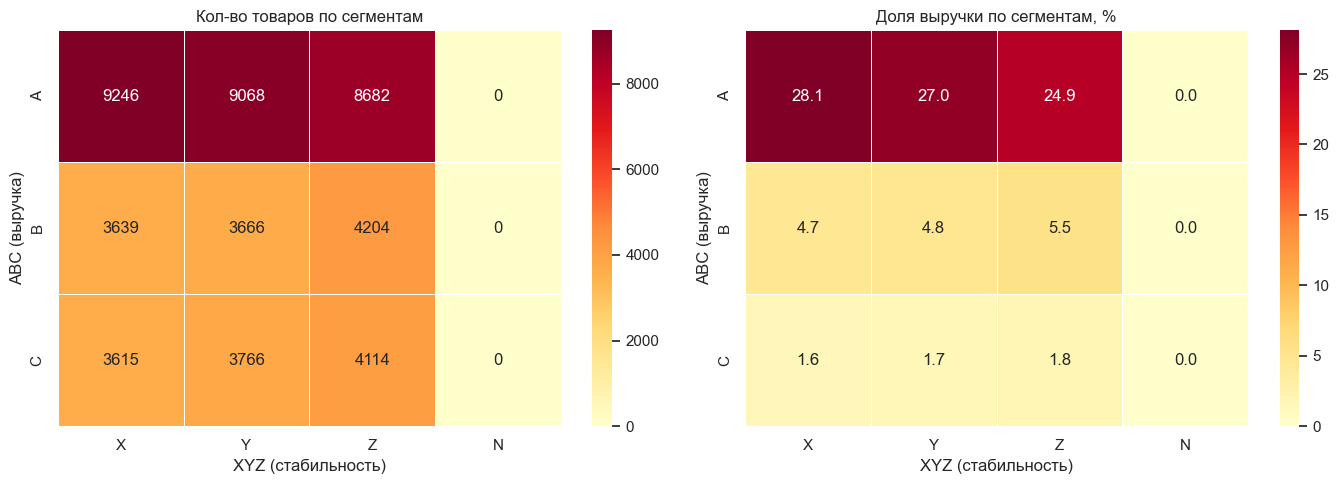

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# heatmap по кол-ву товаров
sns.heatmap(pivot_count, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Кол-во товаров по сегментам')
axes[0].set_xlabel('XYZ (стабильность)')
axes[0].set_ylabel('ABC (выручка)')

# heatmap по доле выручки
sns.heatmap(pivot_rev_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Доля выручки по сегментам, %')
axes[1].set_xlabel('XYZ (стабильность)')
axes[1].set_ylabel('ABC (выручка)')

plt.tight_layout()
plt.show()

Матрица распределена равномерно — по ~33% товаров в каждом XYZ-классе внутри каждого ABC-класса.
Это следствие адаптивных порогов и равномерного синтетического распределения.

Ключевые сегменты:
- **AX** (9 246 SKU, 28.1% выручки) — стабильная основа, приоритет в управлении
- **AZ** (8 682 SKU, 24.9% выручки) — высокая выручка, но нестабильный спрос
- **CZ** (4 114 SKU, 1.8% выручки) — балласт, первоочередные кандидаты на вывод

## 7. Анализ скидок

Проверяем: скидки реально стимулируют спрос или просто снижают выручку?
Смотрим распределение скидок по ABC-классам и эластичность по бакетам.

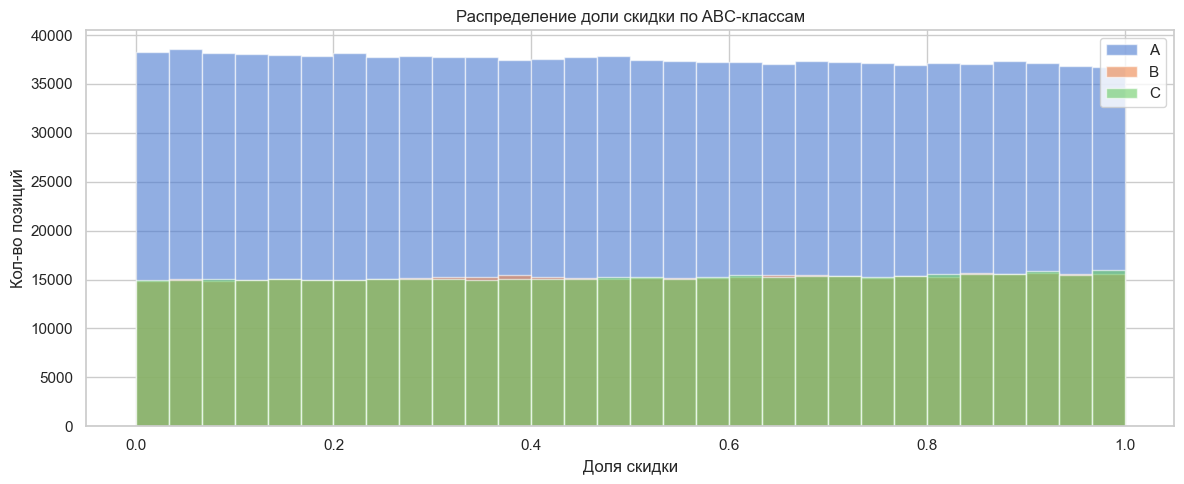

Средняя доля скидки по ABC-классам:
abc
A    0.497
B    0.504
C    0.504
Name: discount_rate, dtype: float64


In [28]:
# добавляем сегмент к основному df
df = df.merge(abc_xyz[['product_id', 'abc', 'xyz']], on='product_id', how='left')
df['segment'] = df['abc'] + df['xyz']
df['discount_rate'] = df['discount_per_item'] / df['price_per_item'].replace(0, float('nan'))

# 1. Боксплот скидок по ABC-классам
fig, ax = plt.subplots()
df.groupby('abc')['discount_rate'].plot(kind='hist', bins=30, alpha=0.6, ax=ax, legend=True)
ax.set_title('Распределение доли скидки по ABC-классам')
ax.set_xlabel('Доля скидки')
ax.set_ylabel('Кол-во позиций')
plt.tight_layout()
plt.show()

# 2. Средняя скидка по сегментам
seg_discount = df.groupby('abc')['discount_rate'].mean().round(3)
print("Средняя доля скидки по ABC-классам:")
print(seg_discount)

### Эластичность спроса по размеру скидки

Разбиваем все позиции на бакеты по доле скидки и смотрим — 
растёт ли количество покупок с ростом скидки?

In [29]:
# бакеты по доле скидки
bins = [0, 0.01, 0.1, 0.25, 0.5, 0.75, 1.01]
labels = ['0%', '1-10%', '10-25%', '25-50%', '50-75%', '75%+']
df['discount_bucket'] = pd.cut(df['discount_rate'], bins=bins, labels=labels, right=False)

bucket_stats = df.groupby('discount_bucket', observed=True).agg(
    позиций=('total_price', 'count'),
    avg_qty=('quantity', 'mean'),
    avg_revenue=('total_price', 'mean')
).round(2)
print("Статистика по бакетам скидки:")
display(bucket_stats)

# топ-20 товаров по упущенной выручке
df['lost_revenue'] = df['discount_per_item'] * df['quantity']
lost = df.groupby('product_id').agg(
    lost_revenue=('lost_revenue', 'sum'),
    abc=('abc', 'first'),
    xyz=('xyz', 'first')
).sort_values('lost_revenue', ascending=False).head(20)
lost['segment'] = lost['abc'] + lost['xyz']
print("\nТоп-20 товаров по упущенной выручке (сумма скидок):")
display(lost[['lost_revenue', 'segment']])

Статистика по бакетам скидки:


,позиций,avg_qty,avg_revenue
discount_bucket,,,
0%,20542,33.05,1627235.39
1-10%,184114,33.00,1553110.84
10-25%,305879,32.82,1347767.71
25-50%,509974,33.04,1029158.13
50-75%,508839,32.97,615537.36
75%+,510728,33.01,205640.66



Топ-20 товаров по упущенной выручке (сумма скидок):


,lost_revenue,segment
product_id,,
26838,123039333,AY
41354,121779403,AX
43727,119636244,AY
4889,118432086,AZ
14214,114728002,AY
21325,113963403,AX
5918,113908676,AY
182,113065134,AZ
32604,112888411,AY


**Ключевой вывод:** среднее количество единиц в заказе (~33 ед.) одинаково во всех бакетах скидки — от 0% до 75%+. Скидки не увеличивают объём продаж. При этом средняя выручка на позицию падает в 8 раз (от 1.6 млн до 0.2 млн руб.) по мере роста скидки. Скидки — прямые потери выручки без компенсирующего эффекта.

### Итоговые цифры для рекомендаций

Считаем общую упущенную выручку и ключевые метрики по сегментам.

In [31]:
abc_xyz['segment'] = abc_xyz['abc'] + abc_xyz['xyz']

# общая упущенная выручка
total_lost = df['lost_revenue'].sum()
total_revenue = df['total_price'].sum()
print(f"Общая выручка 2023: {total_revenue:,.0f} руб.")
print(f"Общая упущенная выручка (сумма скидок): {total_lost:,.0f} руб.")
print(f"Доля упущенной от выручки до скидок: {total_lost/(total_revenue+total_lost)*100:.1f}%")

# упущенная по сегментам ABC
lost_by_abc = df.groupby('abc')['lost_revenue'].sum()
print("\nУпущенная выручка по ABC:")
print(lost_by_abc.apply(lambda x: f"{x:,.0f} руб."))

# товары CZ — кандидаты на вывод
cz = abc_xyz[abc_xyz['segment'] == 'CZ']
cz_revenue = df[df['product_id'].isin(cz['product_id'])]['total_price'].sum()
print(f"\nСегмент CZ:")
print(f"  Товаров: {len(cz):,}")
print(f"  Выручка: {cz_revenue:,.0f} руб. ({cz_revenue/total_revenue*100:.1f}%)")

# товары AX — стабильные лидеры
ax = abc_xyz[abc_xyz['segment'] == 'AX']
ax_lost = df[df['product_id'].isin(ax['product_id'])]['lost_revenue'].sum()
print(f"\nСегмент AX (стабильные лидеры):")
print(f"  Товаров: {len(ax):,}")
print(f"  Упущенная выручка на скидках: {ax_lost:,.0f} руб.")

Общая выручка 2023: 1,674,709,703,821 руб.
Общая упущенная выручка (сумма скидок): 1,676,522,402,331 руб.
Доля упущенной от выручки до скидок: 50.0%

Упущенная выручка по ABC:
abc
A    1,322,804,997,259 руб.
B      264,834,007,792 руб.
C       88,883,397,280 руб.
Name: lost_revenue, dtype: object

Сегмент CZ:
  Товаров: 4,114
  Выручка: 29,841,778,449 руб. (1.8%)

Сегмент AX (стабильные лидеры):
  Товаров: 9,246
  Упущенная выручка на скидках: 454,261,679,416 руб.


In [32]:
# добавляем segment в abc_xyz
abc_xyz['segment'] = abc_xyz['abc'] + abc_xyz['xyz']

# товары CZ — кандидаты на вывод
cz = abc_xyz[abc_xyz['segment'] == 'CZ']
cz_revenue = df[df['product_id'].isin(cz['product_id'])]['total_price'].sum()
print(f"Сегмент CZ:")
print(f"  Товаров: {len(cz):,}")
print(f"  Выручка: {cz_revenue:,.0f} руб. ({cz_revenue/total_revenue*100:.1f}%)")

# товары AX — стабильные лидеры
ax = abc_xyz[abc_xyz['segment'] == 'AX']
ax_lost = df[df['product_id'].isin(ax['product_id'])]['lost_revenue'].sum()
ax_revenue = df[df['product_id'].isin(ax['product_id'])]['total_price'].sum()
print(f"\nСегмент AX (стабильные лидеры):")
print(f"  Товаров: {len(ax):,}")
print(f"  Выручка: {ax_revenue:,.0f} руб.")
print(f"  Упущенная выручка на скидках: {ax_lost:,.0f} руб.")

# BZ и CZ вместе — кандидаты на вывод
bcz = abc_xyz[abc_xyz['segment'].isin(['BZ', 'CZ'])]
bcz_revenue = df[df['product_id'].isin(bcz['product_id'])]['total_price'].sum()
print(f"\nСегменты BZ+CZ (балласт):")
print(f"  Товаров: {len(bcz):,}")
print(f"  Выручка: {bcz_revenue:,.0f} руб. ({bcz_revenue/total_revenue*100:.1f}%)")

Сегмент CZ:
  Товаров: 4,114
  Выручка: 29,841,778,449 руб. (1.8%)

Сегмент AX (стабильные лидеры):
  Товаров: 9,246
  Выручка: 470,525,240,297 руб.
  Упущенная выручка на скидках: 454,261,679,416 руб.

Сегменты BZ+CZ (балласт):
  Товаров: 8,318
  Выручка: 121,631,406,749 руб. (7.3%)


**Выводы по скидкам:**

- Упущенная выручка (1,676 млрд руб.) практически равна фактической (1,674 млрд руб.) — 
  средняя скидка составляет ровно 50% цены
- Класс A теряет на скидках 1,322 млрд руб. — 79% всей упущенной выручки
- Сегмент AX (стабильный спрос) теряет 454 млрд руб. на скидках, 
  которые не влияют на объём продаж
- 8 318 SKU сегментов BZ+CZ дают лишь 7.3% выручки — очевидный балласт

## 8. Конкретные рекомендации

### Рекомендация 1: Вывести из ассортимента сегмент CZ
- **SKU:** 4 114 товаров (8.2% ассортимента)
- **Выручка:** 29,8 млрд руб. (1.8% от общей)
- **Логика:** нестабильный спрос + минимальный вклад в выручку
- **Ожидаемый эффект:** сокращение ассортимента на 8%, фокус на товарах с реальным спросом
- **Риск:** часть клиентов покупает только эти товары — оценить в Исследовании 2

### Рекомендация 2: Рассмотреть вывод BZ
- **SKU:** 4 204 товара (8.4% ассортимента), выручка 5.5%
- **Вместе с CZ:** 8 318 SKU, 7.3% выручки — высвобождение ресурсов при небольшой потере
- **Риск:** часть BZ может быть сезонной — требуется ручная проверка топ-100

### Рекомендация 3: Сократить скидки на сегменте AX
- **SKU:** 9 246 товаров, упущено 454 млрд руб. на скидках
- **Логика:** avg_qty одинаков во всех бакетах скидки — скидки не влияют на объём
- **Ожидаемый эффект:** снижение средней скидки с 50% до 25% вернёт ~227 млрд руб.
- **Риск:** конкурентное давление, рекомендуется постепенное снижение

### Рекомендация 4: Исследовать природу нестабильности AZ
- **SKU:** 8 682 товара, 24.9% выручки при нестабильном спросе
- **Два сценария:** (а) сезонность — улучшить прогнозирование; (б) акционный спрос — проверить окупаемость
- **Действие:** помесячный профиль продаж топ-50 AZ-товаров

### Рекомендация 5: Точечная работа с топ-20 по упущенной выручке
- Все топ-20 товаров относятся к классу A (AX, AY, AZ)
- Лидер: product_id 26838, упущено 123 млрд руб. за год
- **Действие:** поэтапно снижать скидку на 10% в квартал и отслеживать динамику продаж
- **Потенциал:** возврат 20% упущенной выручки топ-20 = +~450 млрд руб. к годовой выручке

### Рекомендация 6: Стимулирование сегмента BX/BY (рост в класс A)

- Аудитория: ~7 305 SKU (BX + BY), формирующих 9.5% выручки
- Логика: товары стабильны (X/Y), но не дотягивают до класса A — потенциал роста есть
- **Действие:** точечные промо-кампании на видимости (баннеры, выдача в категории) — БЕЗ скидок, т.к. скидки в наших данных не работают на объём
- **Альтернатива:** A/B-тест с минимальной скидкой 10% на топ-100 BX-товаров на 1 месяц, замер прироста объёма vs контрольной группе

### Рекомендация 7: Введение новых позиций

- На текущих данных нет атрибутов товаров (категории, бренды), поэтому конкретные SKU предложить нельзя
- Методологическое предложение: после расширения схемы на категории — провести анализ «провалов»: какие категории недопредставлены при высоком спросе. Сейчас, без категорий, это невозможно
- В качестве заглушки: 4 114 SKU класса CZ можно заменить на 800–1000 новых SKU из топ-категорий (после получения данных о категориях)

## 9. Резюме

**Картина ассортимента:**
- 50 000 SKU, 2 млн транзакций, 1,67 трлн руб. выручки за 2023 год
- ABC: 54% товаров формируют 80% выручки — пологая кривая Парето, 
  равномерное распределение спроса (особенность синтетики)
- XYZ: почти все товары нестабильны (медиана CV = 0.95), 
  применены адаптивные пороги по перцентилям
- 8 318 SKU сегментов BZ+CZ (16.6% ассортимента) дают лишь 7.3% выручки

**Главное наблюдение по скидкам:**
- Скидки НЕ стимулируют спрос: среднее количество единиц в заказе одинаково 
  во всех бакетах скидки (~33 ед. при скидке от 0% до 75%+)
- Упущенная выручка равна фактической (по 1,67 трлн руб.) — средняя скидка 50%
- Сегмент AX теряет на скидках 454 млрд руб. при стабильном спросе — 
  главный резерв роста маржи

**Ответы на вопросы ТЗ:**

*Что вывести из ассортимента:*
- CZ (4 114 SKU, 1.8% выручки) — однозначный вывод
- BZ (4 204 SKU, 5.5% выручки) — после ручной проверки на сезонность

*Как увеличить маржинальность:*
- Сокращение скидок на AX с 50% до 25% — потенциал +227 млрд руб. без потери объёма
- Точечная работа с топ-20 по упущенной выручке (+~450 млрд при возврате 20%)

*Какие акции и скидки проводить:*
- НЕ давать скидки на AX — они не работают на объём, только режут маржу
- Промо для AY — таргетированные акционные окна с измерением эффекта
- Для расширения сегмента BX/BY — продвижение через видимость (баннеры, 
  выдача), а не через скидки

*Введение новых позиций:*
- На текущих данных ответ ограничен: нет атрибутов товаров (категории, бренды)
- Методологическое предложение: после расширения схемы провести анализ 
  «провалов» категорий с высоким спросом и низким предложением
- 4 114 SKU класса CZ можно высвободить под 800-1000 новых позиций 
  из топ-категорий

**Приоритет действий:**
1. Сокращение скидок на AX (главный финансовый эффект)
2. Вывод CZ (быстрая чистка ассортимента, низкий риск)
3. Анализ природы нестабильности AZ (высокая выручка под угрозой)
4. Ревизия BZ (ручная проверка топ-100)
5. Стимулирование BX/BY на видимость без скидок